<center><h1>QBUS2820 - Predictive Analytics</h1></center>

# Tutorial 6 - Model Selection and Estimation

Recall that, in Tut 04, we focused on demonstrating the bias-variance decomposition, and in Tut 05 we practiced model selection for KNN.

In Tut 06, we

1) Continue model selection for KNN using alternative built-in CV methods.

2) Model selection in linear regression with CV.

3) Look at how to implement AIC/BIC for model selection in linear regression.


First, let's use the same approach as the previous weeks to simulate some data.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

# Initialise RNG, so we get same result everytime
np.random.seed(0)

# Number of training points
n = 50

x = np.linspace(0.0, 1.0, n)

# Function coefficients/parameters
beta0 = 4
beta1 = 1.5
beta2 = 3.2
 
# f values from 2nd order polynomial
f = beta0 + beta1 * x + beta2 * np.power(x,2)  

# Generate noisy sample from population
sigma2 = 0.1
y_train = f + np.random.normal(0, np.sqrt(sigma2), n)
y_validation = f + np.random.normal(0, np.sqrt(sigma2), n)

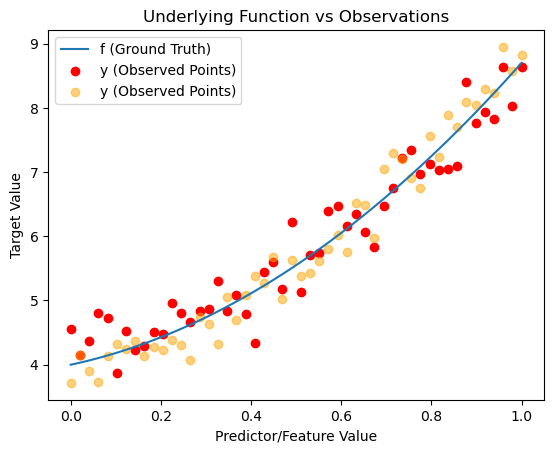

In [4]:
fig1 = plt.figure()

plt.plot(x, f, label = "f (Ground Truth)")
plt.scatter(x, y_train, label = "y (Observed Points)", color = "red")
plt.scatter(x, y_validation, label = "y (Observed Points)", color = "orange", alpha = 0.5)

plt.xlabel("Predictor/Feature Value")
plt.ylabel("Target Value")
plt.title("Underlying Function vs Observations")
plt.legend(loc="upper left")

plt.show()

## Select k in KNN with GridSearchCV

``GridSearchCV`` is an exhaustive search over specified hyperparameter values, which is convenient when you have a few hyperparameters to search for the best combination. In KNN, there is only one hyperparameter, which is ``k``.  


In [6]:
# GridSearchCV
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsRegressor

# Set up the grid of parameters to search (in this case its 1 dimensional)
param_grid = {
    'n_neighbors': np.arange(1,11)
}

model = KNeighborsRegressor()

# Create the grid search object
grid_cv_obj = GridSearchCV(model, param_grid)

# Do the grid search
grid_cv_obj.fit(x.reshape(-1, 1), y_train)

print("Grid Search CV Complete!")

Grid Search CV Complete!


In [7]:
# Get the best model
best_model = grid_cv_obj.best_estimator_

# Print the best model
print(best_model)

KNeighborsRegressor(n_neighbors=4)


In [8]:
# Print the best params
print(grid_cv_obj.best_params_)

{'n_neighbors': 4}


In [9]:
import pandas as pd

results = pd.DataFrame(grid_cv_obj.cv_results_)

results.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_n_neighbors,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.000164,5.820293e-05,0.000309,0.000083,1,{'n_neighbors': 1},-0.081308,-4.900943,-0.322660,0.636097,-1.474163,-1.228595,1.957575,6
1,0.000124,9.122432e-07,0.000240,0.000007,2,{'n_neighbors': 2},-1.379118,-1.497278,0.073428,0.687549,-1.823326,-0.787749,0.984246,3
2,0.000147,3.003522e-05,0.000276,0.000052,3,{'n_neighbors': 3},-1.619946,-1.534856,0.247589,0.868792,-1.403595,-0.688403,1.038912,2
3,0.000128,3.889659e-06,0.000250,0.000010,4,{'n_neighbors': 4},-1.420876,-1.618033,0.414264,0.667964,-1.328431,-0.657022,0.986007,1
4,0.000122,9.725608e-07,0.000239,0.000006,5,{'n_neighbors': 5},-1.613556,-2.656514,0.409688,0.640341,-1.667683,-0.977545,1.283878,4


#### Understanding Grid Search

In this KNN example, we have only one parameter to tune, so the grid is a one-dimensional list. ``GridSearchCV`` performs cross-validation for each value of ``n_neighbors`` and identifies the best value. The ``ParameterGrid`` object in ``sklearn`` helps generate all combinations of parameter values to be checked. In this case, with only the ``n_neighbors`` parameter, there are just 10 combinations to evaluate.

In [11]:
from sklearn.model_selection import ParameterGrid

grid_df = pd.DataFrame(list(ParameterGrid(param_grid)))
                       
grid_df

,n_neighbors
0,1
1,2
2,3
3,4
4,5
5,6
6,7
7,8
8,9
9,10


**GridSearchCV** is particularly convenient for tuning a few hyperparameters. However, when the number of hyperparameters increases, the search space grows exponentially, making the process more computationally intensive. For instance, with three hyperparameters—a (integer from 1 to 10), b (integer from 101 to 110), and c (from -4 to 5)—we would have $10 \times 10 \times 10  = 1000$ combinations to evaluate. The cross-validation process needs to be performed for each combination, which can be computationally expensive. 


Below we show the first 15 rows from the total 1000 rows.

In [13]:
from sklearn.model_selection import ParameterGrid

param_grid = {
    'param_a': np.arange(1,11),
    'param_b': np.arange(101,111),
    'param_c': np.arange(-4,6),
}

grid_df_3 = pd.DataFrame(list(ParameterGrid(param_grid)))
                       
grid_df_3.head(15)

,param_a,param_b,param_c
0,1,101,-4
1,1,101,-3
2,1,101,-2
3,1,101,-1
4,1,101,0
5,1,101,1
6,1,101,2
7,1,101,3
8,1,101,4
9,1,101,5


Total number of combinations of hyperparamters

In [15]:
len(grid_df_3)

1000

## CV for Linear Regression

In [17]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

max_deg = 10

cv_scores_lr = []

for i in range(1, max_deg):
    
    poly_transformer = PolynomialFeatures(i) 
    poly_x = poly_transformer.fit_transform(x.reshape(-1,1))
    
    # Create the linear regression object
    lin_reg = LinearRegression()
    
    # use 3-fold cv
    # https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html
    scores_lr = cross_val_score(lin_reg, poly_x, y_train, cv=3, scoring = 'neg_mean_squared_error')

    # Get the mean of the scores from the 3 folds
    cv_score = np.mean(scores_lr)
    
    cv_scores_lr.append(cv_score)   

### You can change the number of folds in cross validation, and see what is the impact of it on the model selection.

In [19]:
cv_scores_lr

[-0.7677682428258849,
 -0.24718893704797243,
 -1.6382231164262029,
 -11.629631337247547,
 -300.1386596895466,
 -2832.913436184174,
 -10117.513233139038,
 -21932.13243121427,
 -3126766.6191081195]

The optimal Polynomial order

In [21]:
1 + np.argmax(cv_scores_lr)

2

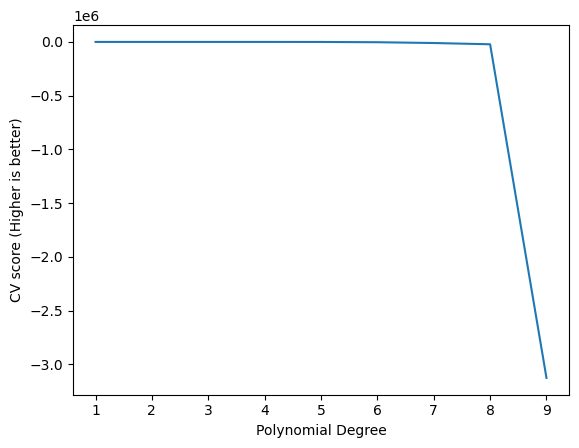

In [22]:
fig = plt.figure()

plt.plot(np.arange(1,max_deg), cv_scores_lr)

plt.xlabel("Polynomial Degree")
plt.ylabel("CV score (Higher is better)")
plt.show()

Note the in the above plot the extreme values, e.g. -3126766.599, make the pattern of the plot not clear. Let's only plot CV score versus the first 4 polynomial orders.

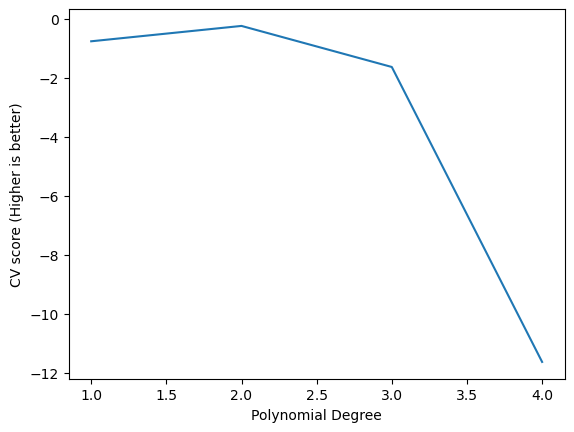

In [24]:
fig = plt.figure()

plt.plot(np.arange(1,5), cv_scores_lr[0:4])

plt.xlabel("Polynomial Degree")
plt.ylabel("CV score (Higher is better)")
plt.show()

## Using CV to Evaluate Model Performance

Let's compare the performance of the best polynomial regression model with the KNN regressor.

To ensure that each model uses the same K-Folds for cross-validation, we need to store the K-Fold split into a Python object and sharing it with the ``cross_val_score`` function for both models.

In [26]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# Build poly2 model
poly_transformer = PolynomialFeatures(2) 
poly_x = poly_transformer.fit_transform(np.reshape(x, (-1,1)))
poly_reg = LinearRegression()
poly_reg.fit(poly_x, y_train)
    
# Build knn model
knn = KNeighborsRegressor(n_neighbors= 4)
knn.fit(x.reshape(-1,1), y_train)

KNeighborsRegressor(n_neighbors=4)

In [27]:
from sklearn.model_selection import KFold

# 3-Fold Cross Validation
kf = KFold(3)

poly_scores = cross_val_score(poly_reg, poly_x, y_train, cv = kf)
poly_mean = np.mean(poly_scores)

knn_scores = cross_val_score(knn, x.reshape(-1,1), y_train, cv = kf)
knn_mean = np.mean(knn_scores)

In [28]:
# Make the results pretty

data = [
    {"Model": "Polynomial Regression", "CV score": poly_mean},
    {"Model": "KNN Regressor", "CV score": knn_mean}
]

results = pd.DataFrame(data)
results = results.set_index("Model")
results

,CV score
Model,
Polynomial Regression,-0.63556
KNN Regressor,-1.74397


## Model selection with AIC and BIC in linear regression

Consider a linear regression model with response vector $y$ and design matrix $X$. Let 
$\hat{\sigma}^2=\frac{1}{n}(y-X\widehat\beta)^\top(y-X\widehat\beta)$
be the estimate of the variance of error term $\epsilon$. The AIC and BIC are given by

$$AIC=n\log(\hat{\sigma}^2)+2d,$$

$$BIC=n\log(\hat{\sigma}^2)+\log(n)d,$$

where $n$ is the number of boservations and $d$ is the total number of parameters. For those interested in the derivation of AIC and BIC for the linear regression model, please refer to the detailed explanation  [here](https://robjhyndman.com/hyndsight/lm_aic.html).

Now, let's simulate data as in Tutorial 04 and see how AIC/BIC work as model selection techniques. The data is generated from the following model:

$y = \beta_0 + \beta_1 x + \beta_2 x^2 +\epsilon,$

We compare the following potential models:

$y = \beta_0 + \beta_1 x +\epsilon$

$y = \beta_0 + \beta_1 x + \beta_2 x^2 +\epsilon$

$y = \beta_0 + \beta_1 x + \beta_2 x^2 +\beta_3 x^3+\epsilon$

For the $k$-polynomial regression model, the total number of parameters is $d=k+2$ (why? - $k$ coefficients, an intercept, and the variance parameter $\sigma^2$.)

In [30]:
import numpy as np
import matplotlib.pyplot as plt

# Initialise RNG, so we get same result everytime
np.random.seed(0)

# Number of training points
n = 100
x = np.linspace(0.0, 1.0, n)

# true coefficients/parameters
beta0 = 4
beta1 = 1.5
beta2 = 3.2
 
# generate data  
sigma2 = 0.1
y = beta0 + beta1 * x + beta2 * np.power(x,2) + np.random.normal(0, np.sqrt(sigma2), n)

Calculate AIC and BIC values for the three models.

In [32]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression

max_deg = 4
aic = list()
bic = list()

for k in range(1, max_deg):
    
    poly_transformer = PolynomialFeatures(k) 
    poly_x = poly_transformer.fit_transform(x.reshape(-1,1))
    
    # Create the linear regression object
    lin_reg = LinearRegression()

    # Estimate coefficients
    lin_reg.fit(poly_x, y)
    
    # Calculate predictions
    y_pred = lin_reg.predict(poly_x)
    
    # Calcualte sigma2_hat
    sigma2_hat = mean_squared_error(y, y_pred)
    
    number_of_parameters = k+2
    
    aic_value = n*np.log(sigma2_hat)+2*number_of_parameters
    bic_value = n*np.log(sigma2_hat)+np.log(n)*number_of_parameters
    
    aic.append(aic_value)
    bic.append(bic_value)
    

In [33]:
aic

[-145.12914244244615, -238.13407604531412, -236.1516005462048]

In [34]:
bic

[-137.31363188448188, -227.71339530136174, -223.12574961626433]